In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import seaborn as sns

In [ ]:
def generator_comp(llm_results_dict, metrics = ['BLEU','ROUGE-1','BERT P','BERT R','BERT F1','Perplexity']):
    '''
    Create Bar Chart comparing Generator scores
    '''
    llms = list(llm_results_dict.keys())
    data = {metric: [llm_results_dict[llm][metric] for llm in llms] for metric in metrics}
    rag_comparison_df = pd.DataFrame(data, index = llms).reset_index()
    rows = int(np.ceil(len(metrics)/3))
    fig, axes = plt.subplots(rows, 3, figsize=(25, 15))
    axes = axes.flatten()
    for x, score in enumerate(rag_comparison_df.columns[1:]):
        score_data = rag_comparison_df[["index",score]]
        # axes[x].bar(score_data["index"], score_data[score])
        sns.barplot(score_data,x="index",y = score, hue = "index" ,palette = "gist_earth",ax = axes[x])
        axes[x].set_title(f"Score: {score}", fontsize =20)
        axes[x].set_xlabel(None)
        axes[x].tick_params(axis='x', labelsize=12) 
        axes[x].set_ylabel(f"{score}", fontsize =12)
    return fig
    

In [3]:
def retrieval_comp_by_query(llm_results_dict):
    '''
    Create bar chart comparing retriever scores for each question
    '''
    relevance_score_dict = {}
    ticker_relevance_dict = {}

    for llm in llm_results_dict.keys():
        llm_results_query = llm_results_dict[llm]["query_results_retriever"]
        relevance_scores = [llm_results_query[query]["relevance_score"] for query in llm_results_query]
        relevance_score_dict[llm] = relevance_scores

        ticker_relevance_scores = [llm_results_query[query]["ticker_relevance_accuracy"] for query in llm_results_query]
        ticker_relevance_dict[llm] = ticker_relevance_scores

    relevance_score_df = pd.DataFrame(relevance_score_dict).reset_index()
    relevance_score_df_long = relevance_score_df.melt('index', var_name='rag', value_name='relevance_score')

    ticker_relevance_df = pd.DataFrame(ticker_relevance_dict).reset_index()
    ticker_relevance_df_long = ticker_relevance_df.melt('index', var_name='rag', value_name='ticker_relevance')

    fig, axes = plt.subplots(2, 1, figsize=(15, 15))
    
    sns.barplot(relevance_score_df_long, x="index", y="relevance_score", hue="rag", palette="gist_earth",legend=True, ax = axes[0])
    axes[0].set_xlabel("Question ID")
    axes[0].set_ylabel("Relevance Score")
    axes[0].set_title('Relevance Score')
    axes[0].legend(title="RAG Model")
    sns.barplot(ticker_relevance_df_long, x="index", y="ticker_relevance", hue="rag", palette="gist_earth",legend=True, ax = axes[1])
    axes[1].set_xlabel("Question ID")
    axes[1].set_ylabel("Retrieved Ticker Accuracy")
    axes[1].set_title('Retrieved Ticker Accuracy')
    axes[1].legend(title="RAG Model")


In [4]:
def retrieval_comp_average(llm_results_dict):
    '''
    Create bar chart comparing average retriever scores accross all questions
    '''
    rag_comparison_dict ={}
    llms = llm_results_dict.keys()
    rag_comparison_dict["avg_relevance_score"] = [llm_results_dict[llm]["avg_relevance_score"] for llm in llms]
    rag_comparison_dict["relevant_ticker_accuracy"] = [llm_results_dict[llm]["relevant_ticker_accuracy"] for llm in llms]
    rag_comparison_df = pd.DataFrame(rag_comparison_dict,index = llms).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    sns.barplot(rag_comparison_df, x="index", y="avg_relevance_score", hue="index", palette="gist_earth",legend=False, ax = axes[0])
    axes[0].set_xlabel("RAG Model")
    axes[0].set_ylabel("Average Relevance Score")
    axes[0].set_title('Average Relevance Score')
    sns.barplot(rag_comparison_df, x="index", y="relevant_ticker_accuracy", hue="index", palette="gist_earth",legend=False, ax = axes[1])
    axes[1].set_xlabel("RAG Model")
    axes[1].set_ylabel("Retrieved Ticker Accuracy")
    axes[1].set_title('Retrieved Ticker Accuracy')


In [5]:
def query_times_comp(llm_results_dict):
    '''
    Create line graph comparing query times accross each question
    '''
    rag_comparison_dict ={}
    for llm in llm_results_dict.keys():
        query_times = llm_results_dict[llm]["query_times"].values()
        rag_comparison_dict[llm] = query_times
    rag_comparison_df = pd.DataFrame(rag_comparison_dict).reset_index()
    rag_comparison_df_long = rag_comparison_df.melt('index', var_name='rag', value_name='time')

    sns.lineplot(rag_comparison_df_long, x="index", y="time", hue="rag", palette="gist_earth",legend=True)
    plt.title("Question Execution Times")
    plt.xlabel("Question ID")
    plt.ylabel("Query Time (s)")
    plt.legend(title = "RAG Model")
    plt.xticks(np.arange(20))
    return plt
    

In [6]:
def compare_avg_times(llm_results_dict):
    '''
    Create bar chart comparing average query times
    '''
    llms = list(llm_results_dict.keys())
    data = {"avg_query_time": [llm_results_dict[llm]["avg_query_time"] for llm in llms]}
    rag_comparison_df = pd.DataFrame(data, index = llms).reset_index()
    sns.barplot(rag_comparison_df, x="avg_query_time", y="index", hue="index", palette="gist_earth",legend=False)
    plt.title("Average Query Execution Times")
    plt.ylabel(None)
    plt.xlabel("Avg Query Time (s)")
    return plt

<h1> Compare HTML Parsing Methods </h1>

In [7]:
# These three models were produced using a RetrievalQA Chain with the default cosine similarity retriever
# The LLM model used for the generator is deepseek-r1
# The only difference is the parsing method used to convert the HTML files into the vector store

In [8]:
#manual parsing of html data using beautiful soup and regex
with open('./score_dicts/rag_scores_model_1.json', 'r') as json_file:
    rag_model_1_scores = json.load(json_file)

#Beautiful soup to bring in text and then use sematic chunker on entire document
with open('./score_dicts/rag_scores_model_2.json', 'r') as json_file:
    rag_model_2_scores = json.load(json_file)

#Beautiful soup to bring in text and then use regex to split into sections and use semantic chunker on those sections
with open('./score_dicts/rag_scores_model_3.json', 'r') as json_file:
    rag_model_3_scores = json.load(json_file)

<h4> Generator Score Comparisons </h4>

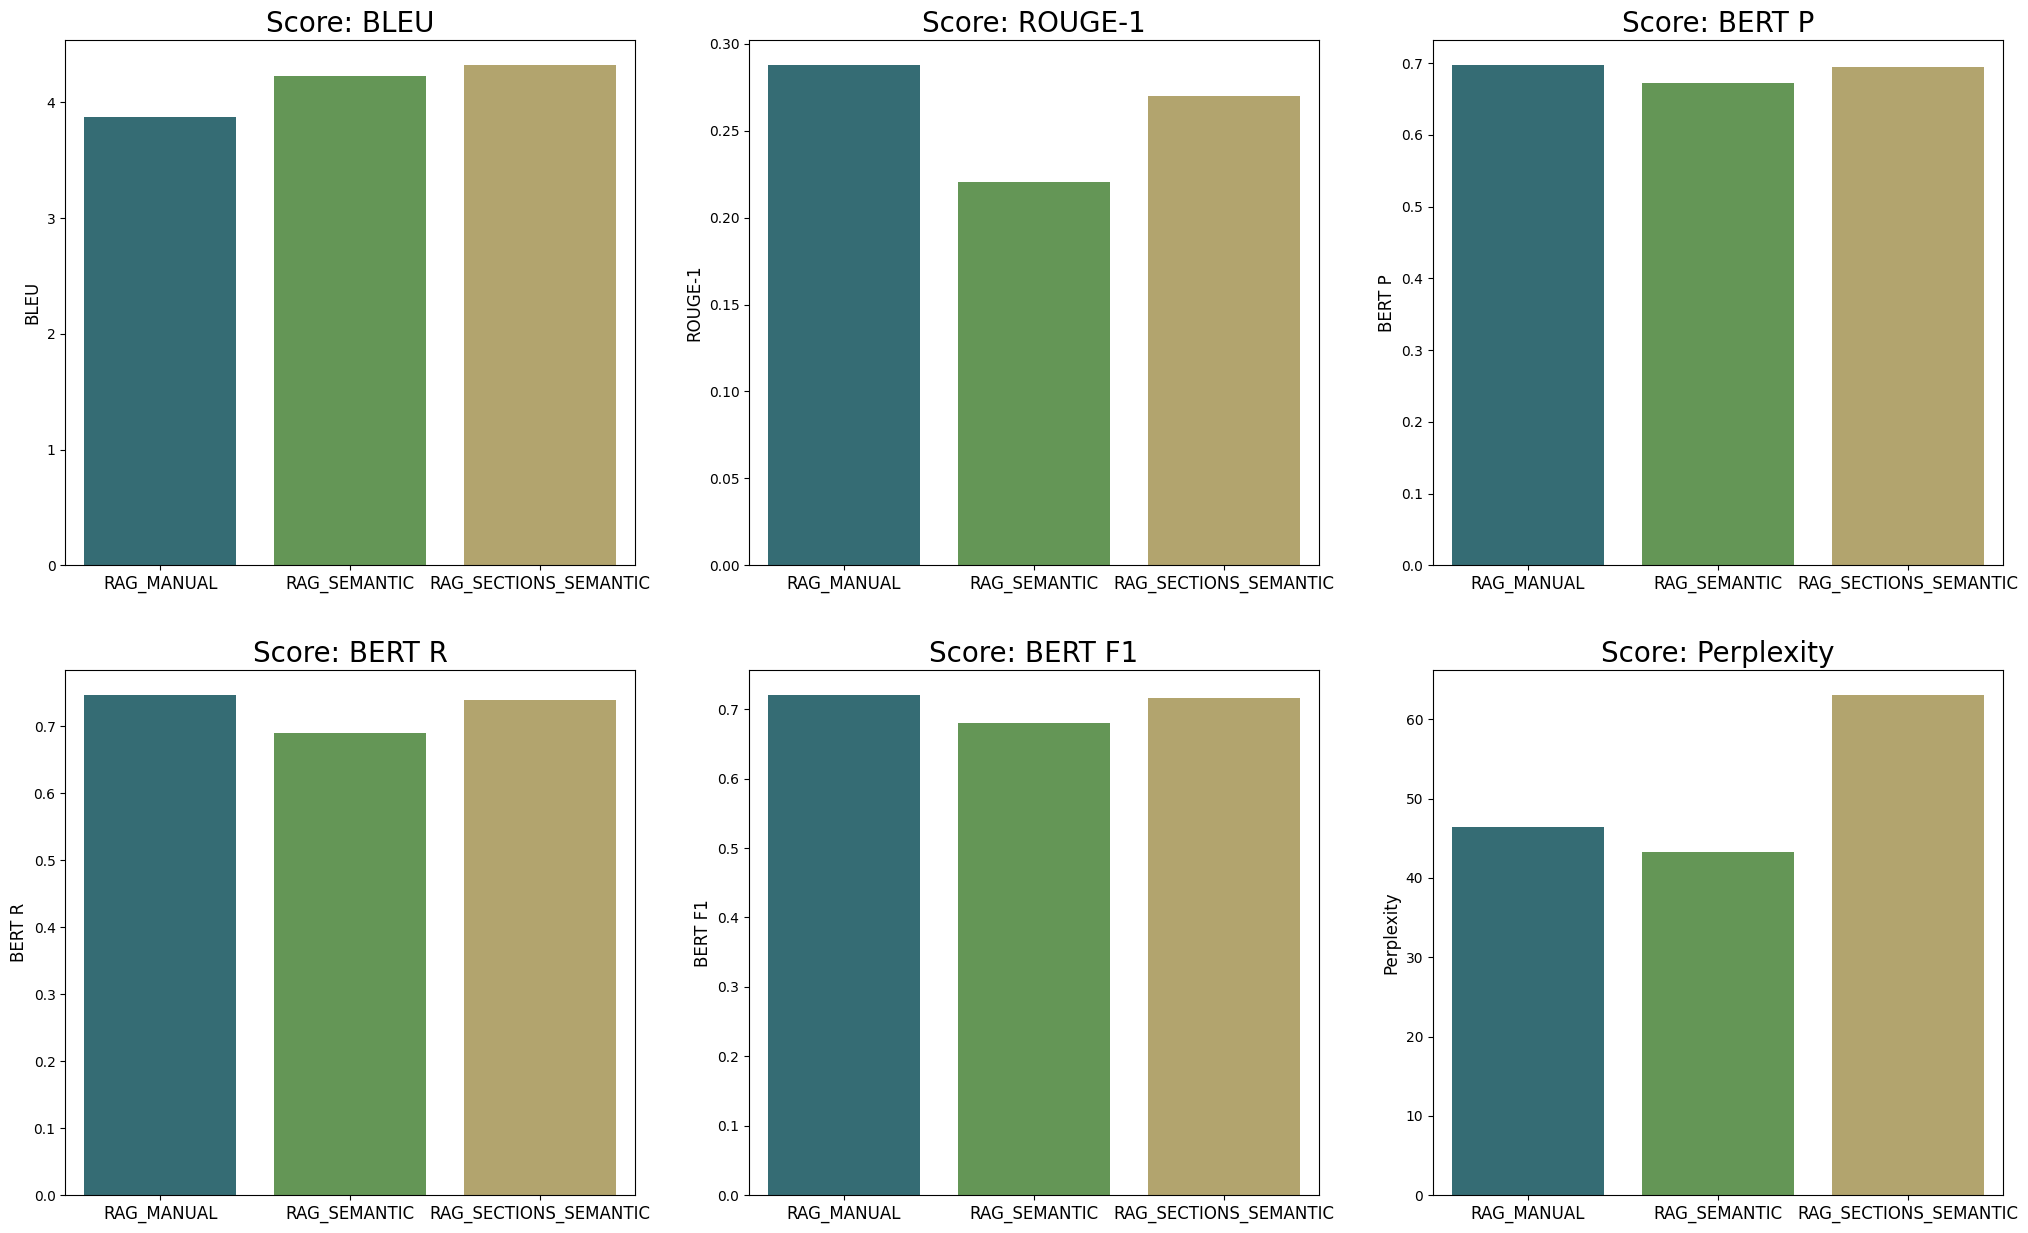

In [9]:
llm_results = {
    "RAG_MANUAL": rag_model_1_scores["generator_scores"]["average_metrics_generator"],
    "RAG_SEMANTIC": rag_model_2_scores["generator_scores"]["average_metrics_generator"],
    "RAG_SECTIONS_SEMANTIC":rag_model_3_scores["generator_scores"]["average_metrics_generator"]
}
generator_comp_1 = generator_comp(llm_results)

<h4> Retrieval Score Comparisons </h4>

In [10]:
llm_results = {
    "RAG_MANUAL": rag_model_1_scores["retrieval_scores"],
    "RAG_SEMANTIC": rag_model_2_scores["retrieval_scores"],
    "RAG_SECTIONS_SEMANTIC":rag_model_3_scores["retrieval_scores"]
}

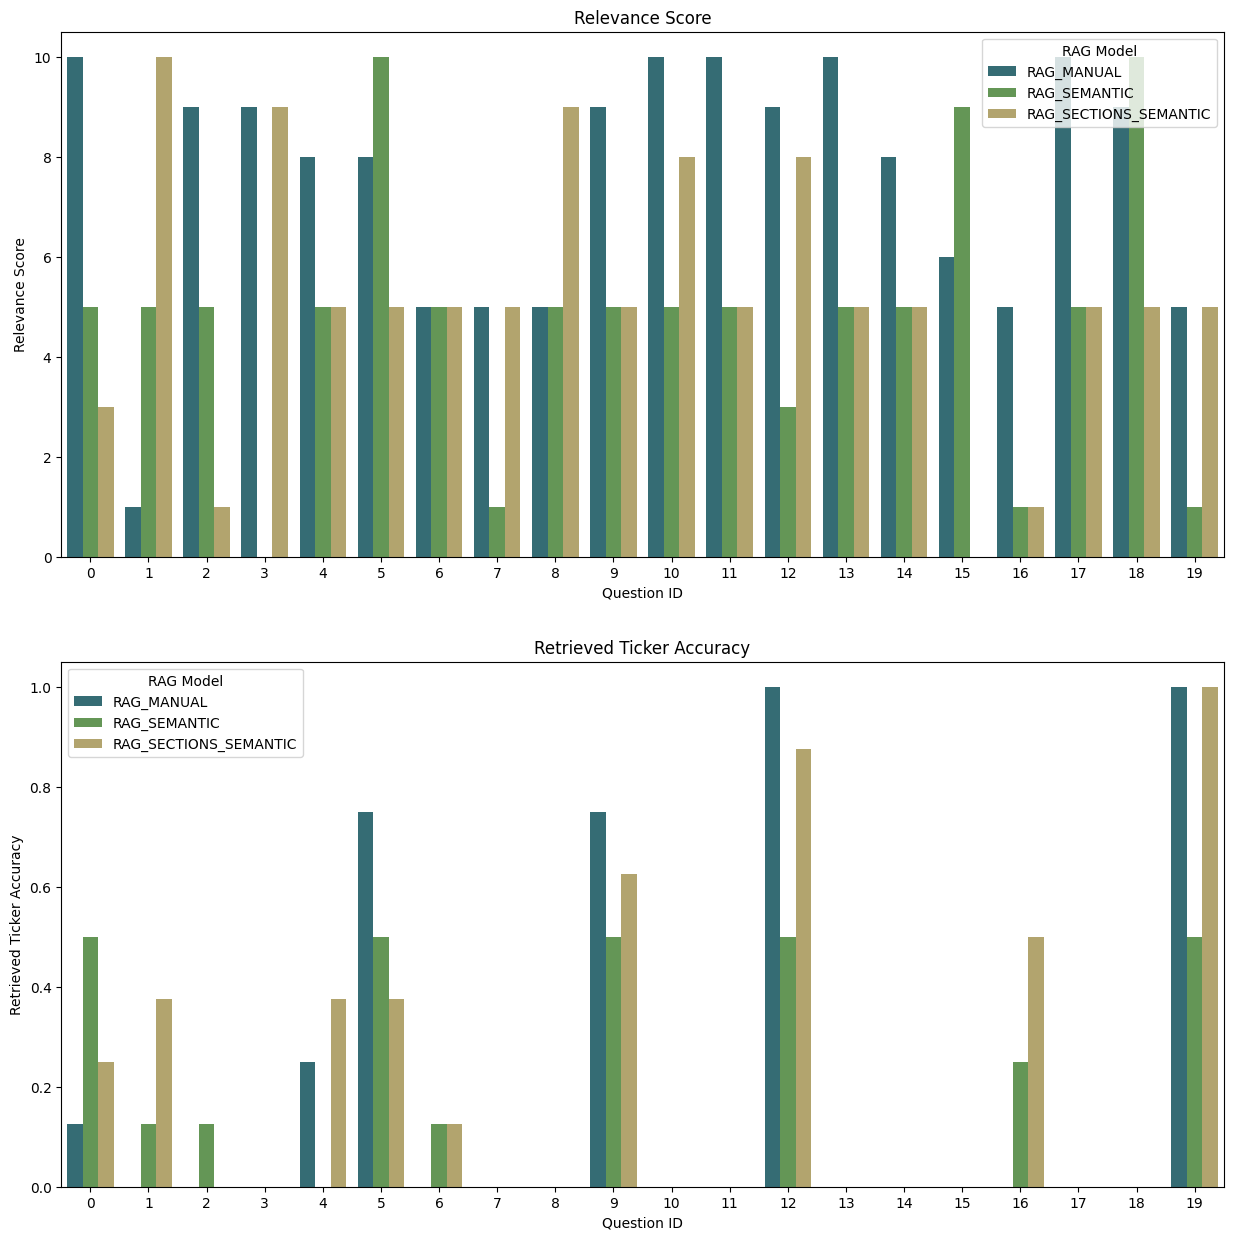

In [11]:
retrieval_comp_by_query(llm_results)

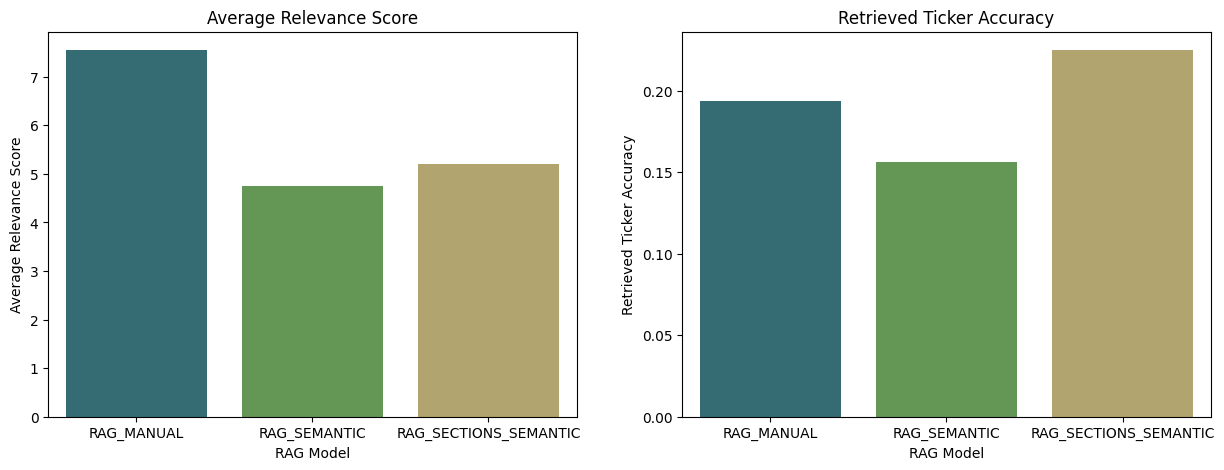

In [12]:
retrieval_comp_average(llm_results)

<h4> Query Time Comparisons </h4>

In [13]:
llm_comps = {
    "RAG_MANUAL": rag_model_1_scores["query_time_results"],
    "RAG_SEMANTIC": rag_model_2_scores["query_time_results"],
    "RAG_SECTIONS_SEMANTIC":rag_model_3_scores["query_time_results"]
}

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

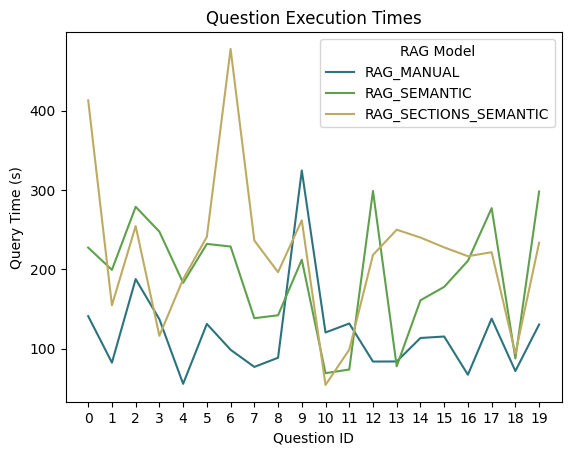

In [14]:
query_times_comp(llm_comps)

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

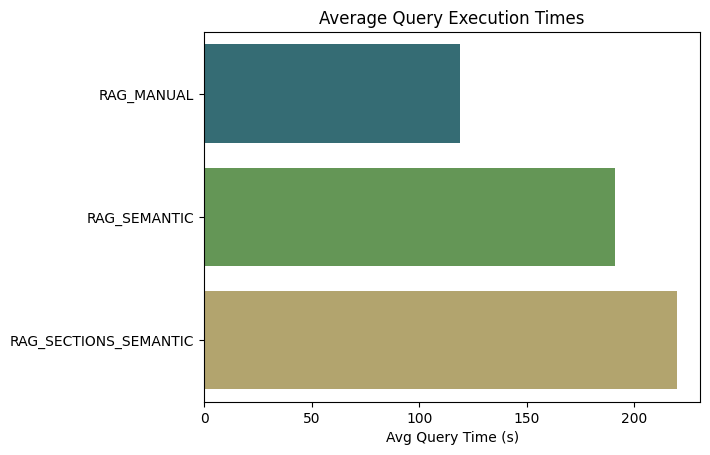

In [15]:
compare_avg_times(llm_comps)


<h1> Compare Generator Models </h1>

In [16]:
# These three models were produced using a RetrievalQA Chain with the default cosine similarity retriever
# The parsing method to create the vector store is the semantic chunker
# The difference is in the LLM model used for the generator: deepseek-r1 (Model 2), mistral-nemo (Model 4), and llama 3.2 (Model 5 )

In [17]:
#manual parsing of html data using beautiful soup and regex
with open('./score_dicts/rag_scores_model_2.json', 'r') as json_file:
    rag_model_2_scores = json.load(json_file)

#Beautiful soup to bring in text and then use sematic chunker on entire document
with open('./score_dicts/rag_scores_model_4.json', 'r') as json_file:
    rag_model_4_scores = json.load(json_file)

#Beautiful soup to bring in text and then use regex to split into sections and use semantic chunker on those sections
with open('./score_dicts/rag_scores_model_5.json', 'r') as json_file:
    rag_model_5_scores = json.load(json_file)

Generator Score Comparisons

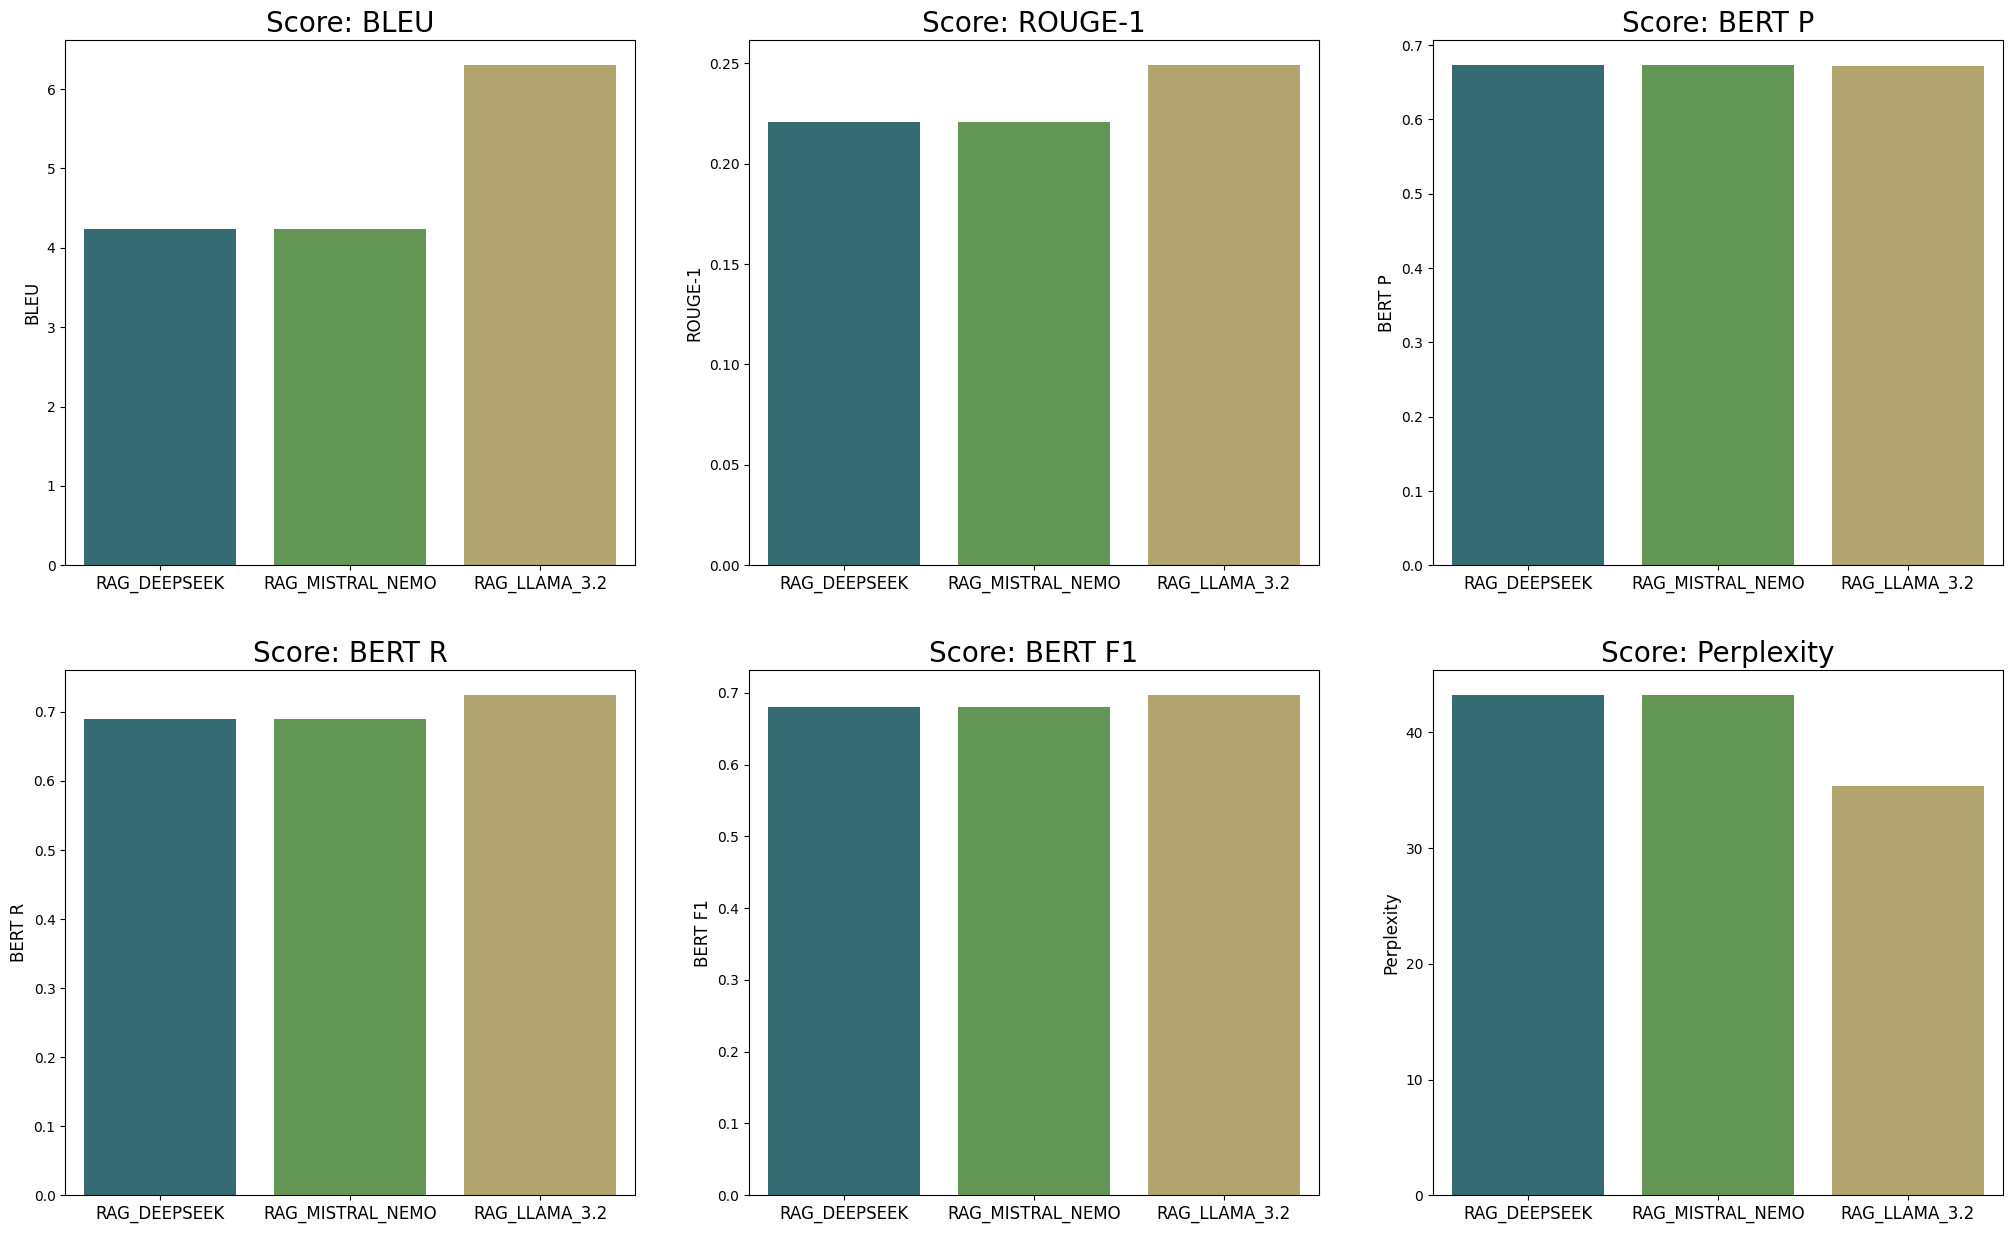

In [18]:
llm_results = {
    "RAG_DEEPSEEK": rag_model_2_scores["generator_scores"]["average_metrics_generator"],
    "RAG_MISTRAL_NEMO": rag_model_4_scores["generator_scores"]["average_metrics_generator"],
    "RAG_LLAMA_3.2":rag_model_5_scores["generator_scores"]["average_metrics_generator"]
}
generator_comp_2 = generator_comp(llm_results,metrics = ['BLEU','ROUGE-1','BERT P','BERT R','BERT F1','Perplexity'])

Retrieval Score Comparisons

In [19]:
llm_results = {
    "RAG_DEEPSEEK": rag_model_2_scores["retrieval_scores"],
    "RAG_MISTRAL_NEMO": rag_model_4_scores["retrieval_scores"],
    "RAG_LLAMA_3.2":rag_model_5_scores["retrieval_scores"]
}

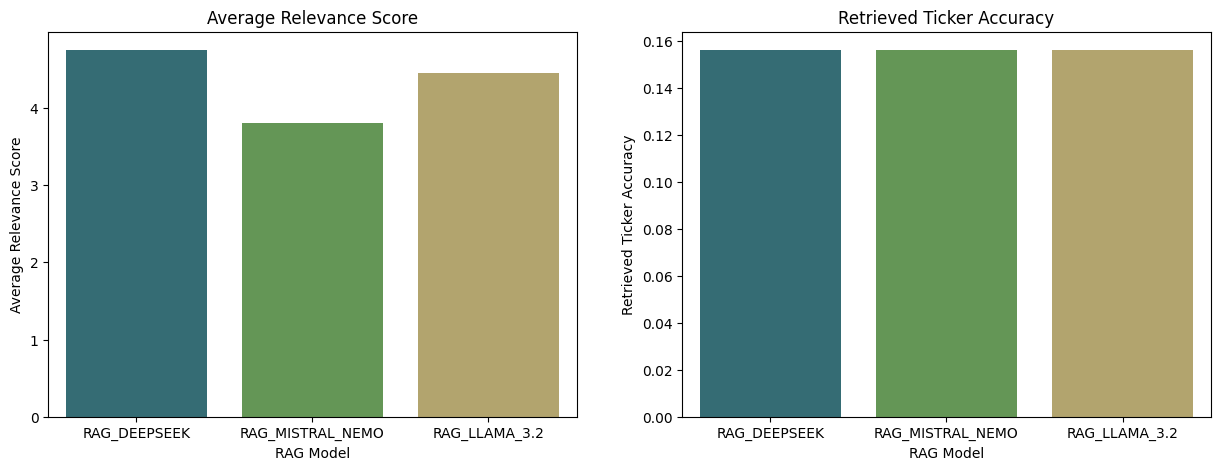

In [20]:
retrieval_comp_average(llm_results)

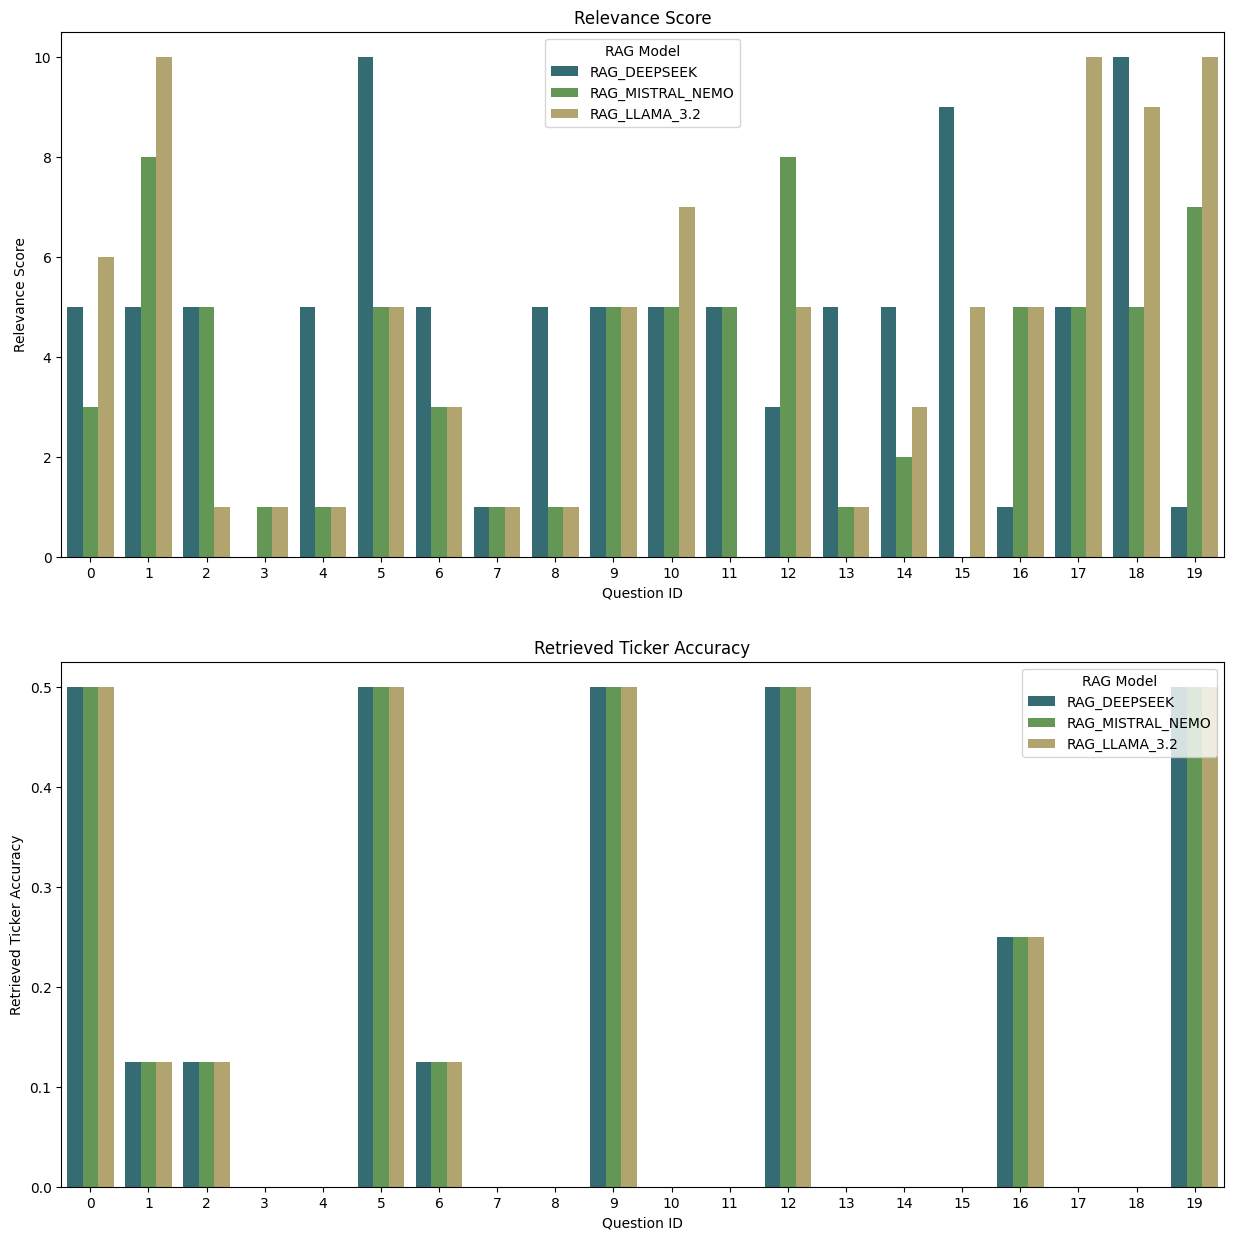

In [21]:
retrieval_comp_by_query(llm_results)

Query Time Comparison

In [22]:
llm_comps = {
    "RAG_DEEPSEEK": rag_model_2_scores["query_time_results"],
    "RAG_MISTRAL_NEMO": rag_model_4_scores["query_time_results"],
    "RAG_LLAMA_3.2":rag_model_5_scores["query_time_results"]
}

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

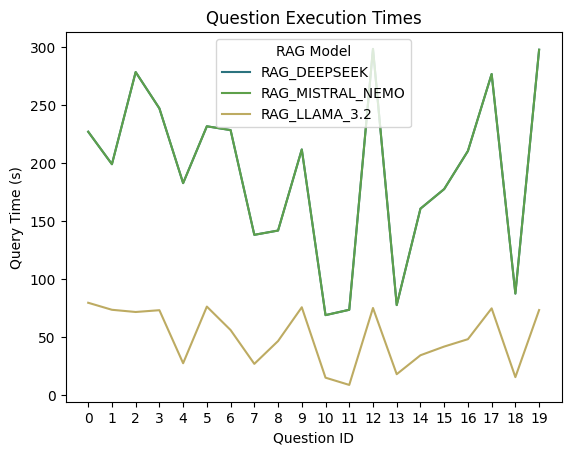

In [23]:
query_times_comp(llm_comps)

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

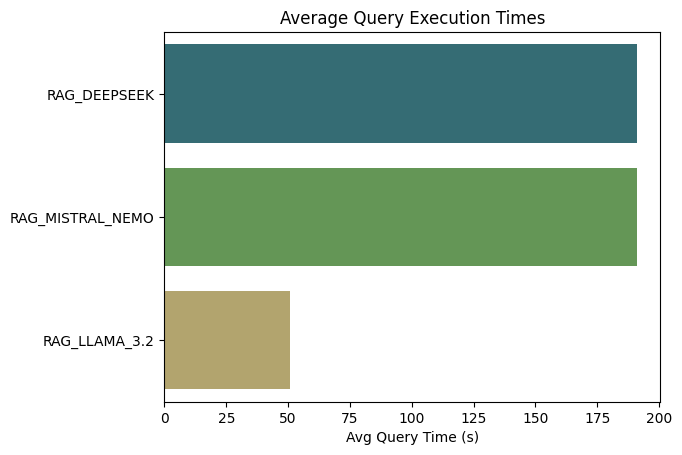

In [24]:
compare_avg_times(llm_comps)

<h1> Compare Retriever Type </h1>

In [ ]:
# These four models were produced using the beautiful soup parsed vector store
# The generator model used was llama 3.2 for all 
# Model 8 (Final Model) was produced with RetrievalQA Chain with the default cosine similarity retriever
# Model 6 used a SelfQueryRetriever instead of the default cosine similary
# Model 9 was produced using a similarity score threshold of 0.25
# Model 10 was produced using MMR instead of cosine similarity

In [26]:
#FINAL MODEL
with open('./score_dicts/rag_scores_model_8.json', 'r') as json_file:
    rag_model_8_scores = json.load(json_file)

with open('./score_dicts/rag_scores_model_6.json', 'r') as json_file:
    rag_model_6_scores = json.load(json_file)

with open('./score_dicts/rag_scores_model_9.json', 'r') as json_file:
    rag_model_9_scores = json.load(json_file)

with open('./score_dicts/rag_scores_model_10.json', 'r') as json_file:
    rag_model_10_scores = json.load(json_file)

Generator Scores Comparison

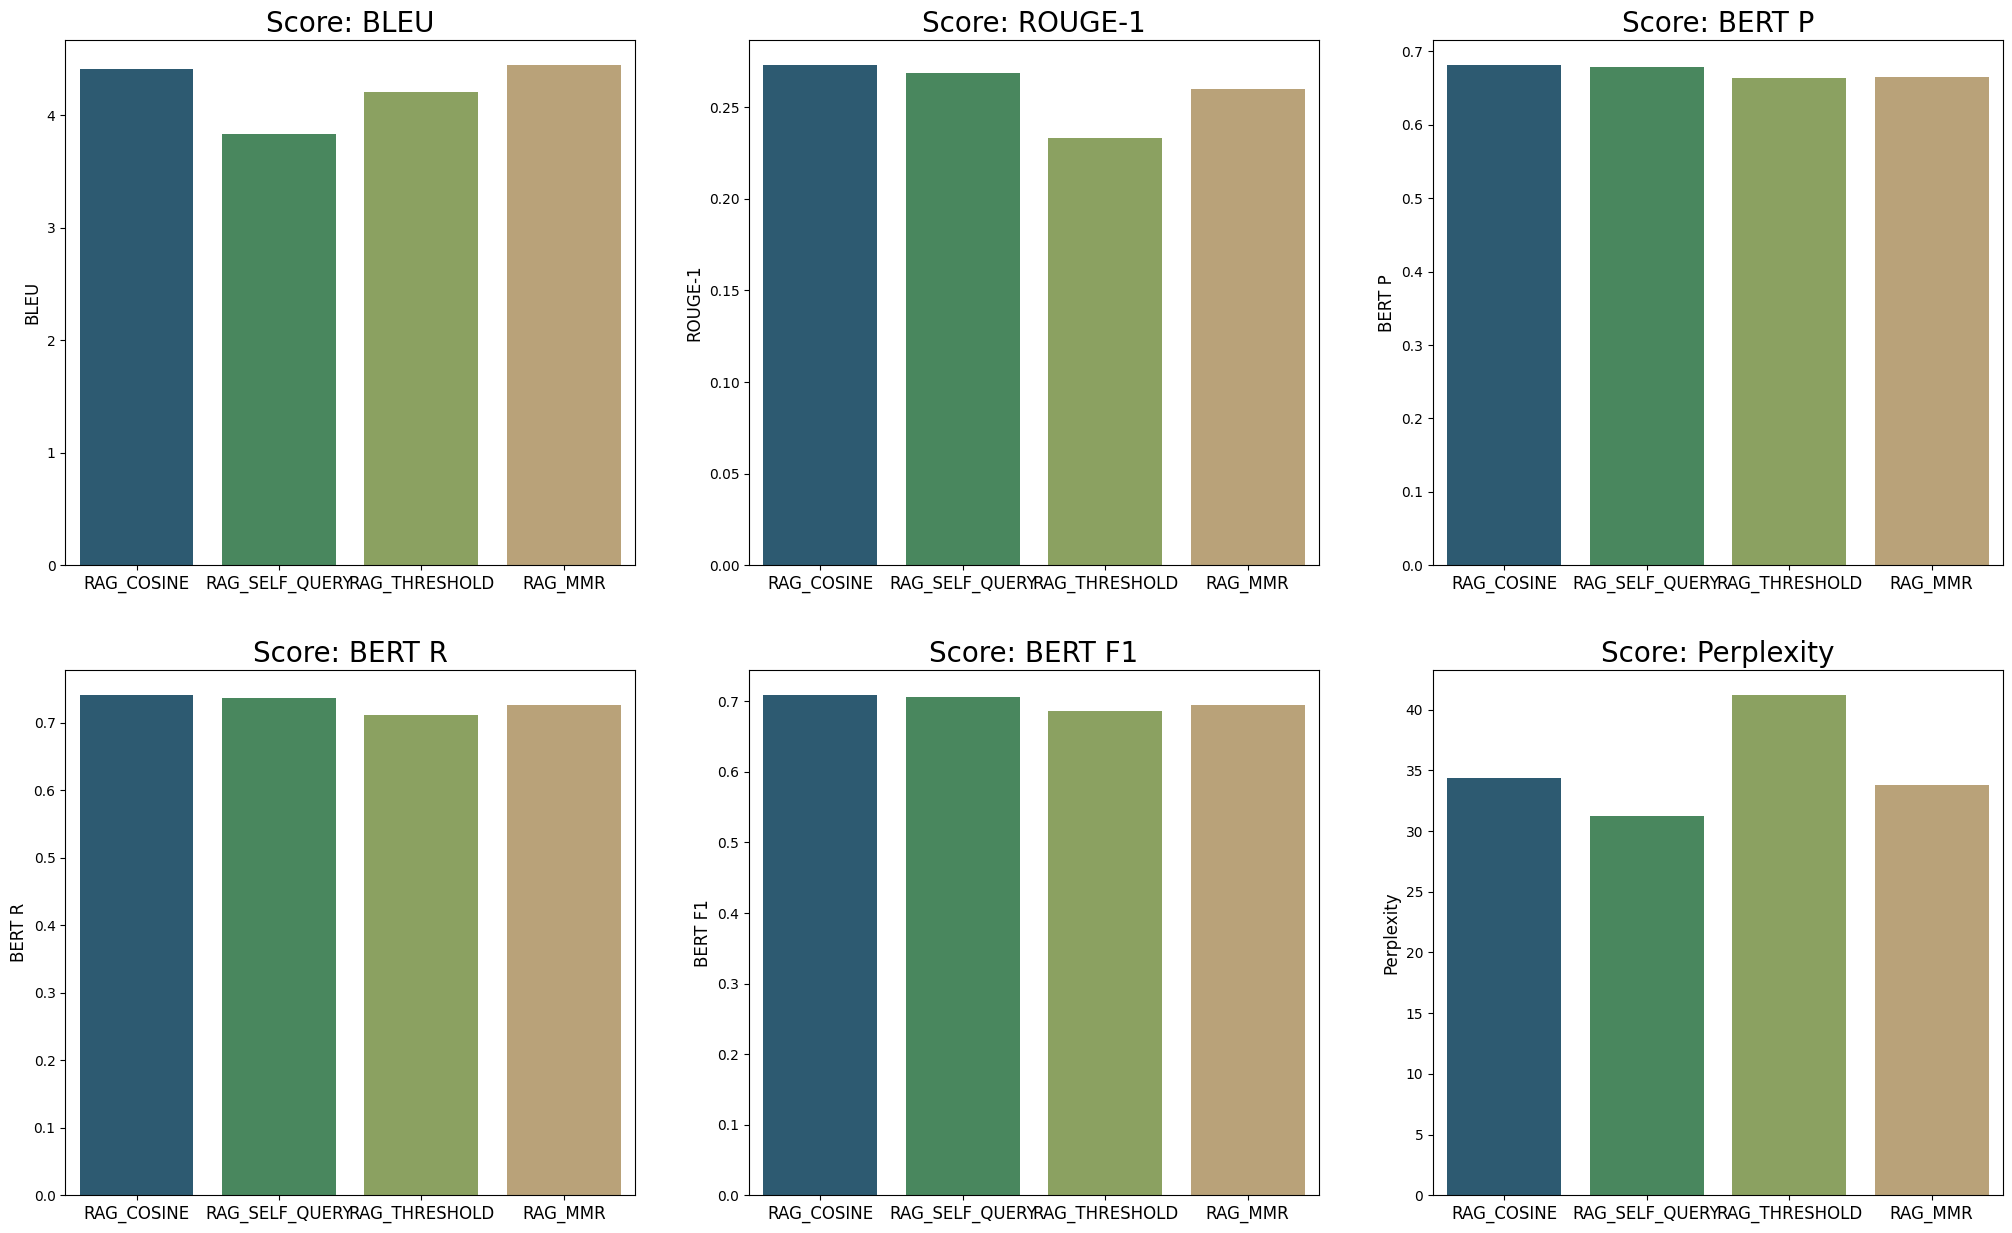

In [27]:
llm_results = {
    "RAG_COSINE": rag_model_8_scores["generator_scores"]["average_metrics_generator"],
    "RAG_SELF_QUERY": rag_model_6_scores["generator_scores"]["average_metrics_generator"],
    "RAG_THRESHOLD": rag_model_9_scores["generator_scores"]["average_metrics_generator"],
    "RAG_MMR": rag_model_10_scores["generator_scores"]["average_metrics_generator"]
}
generator_comp_3 = generator_comp(llm_results)

Retriever Score Comparisons

In [28]:
llm_results = {
    "RAG_COSINE": rag_model_8_scores["retrieval_scores"],
    "RAG_SELF_QUERY": rag_model_6_scores["retrieval_scores"],
    "RAG_THRESHOLD": rag_model_9_scores["retrieval_scores"],
    "RAG_MMR": rag_model_10_scores["retrieval_scores"]
}

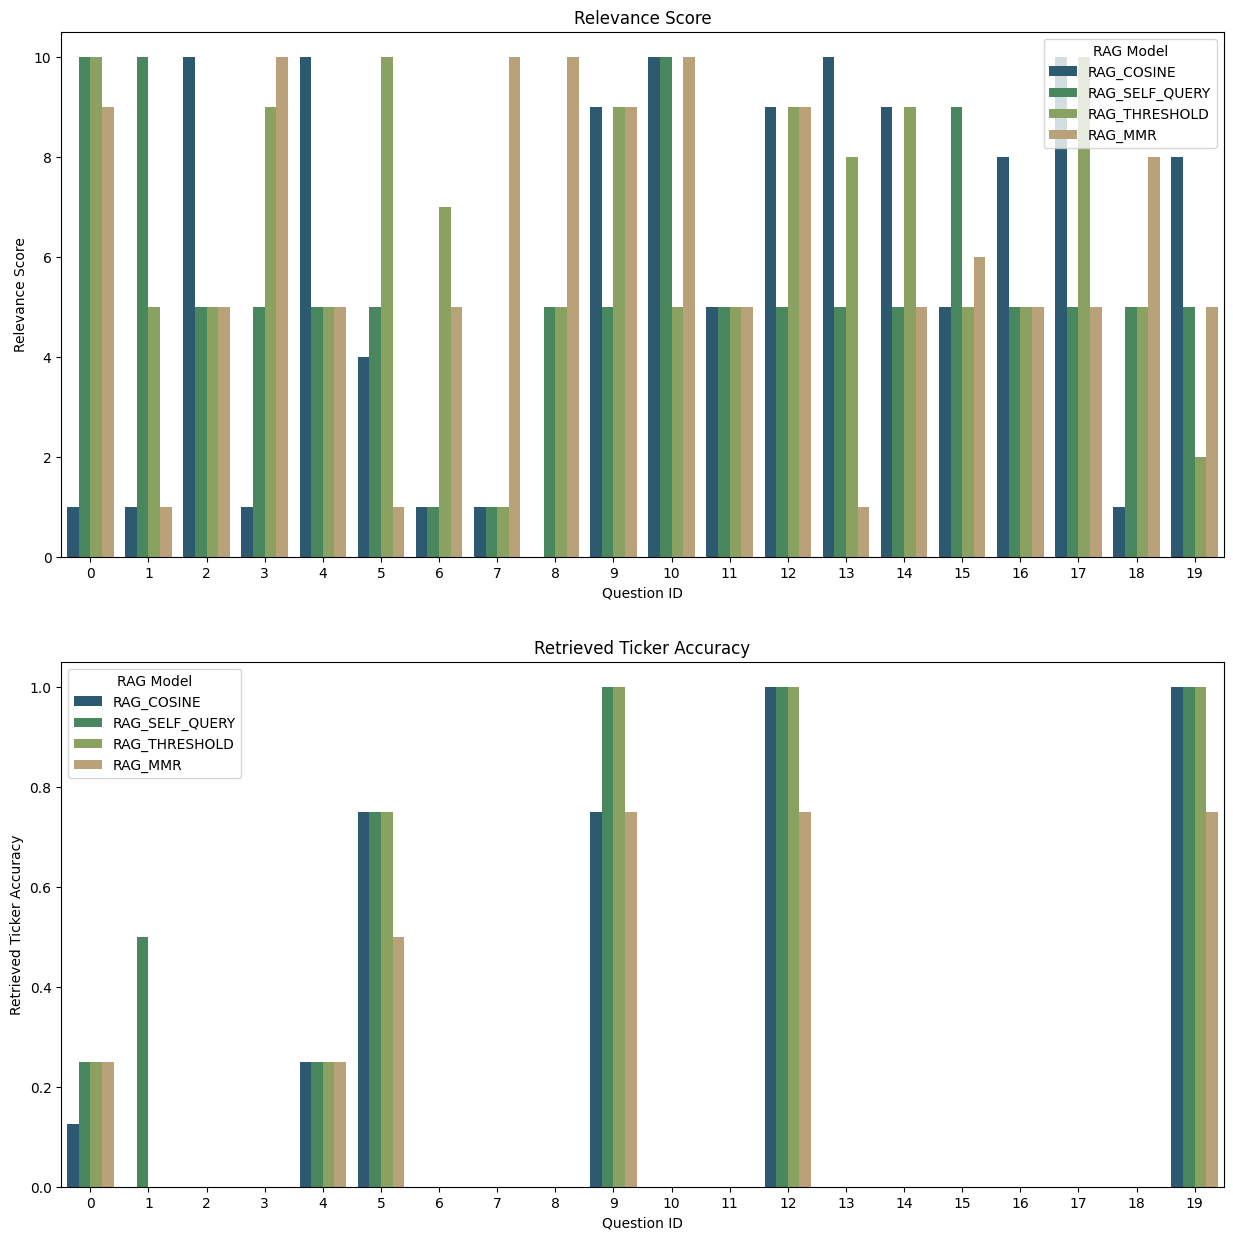

In [29]:
retrieval_comp_by_query(llm_results)

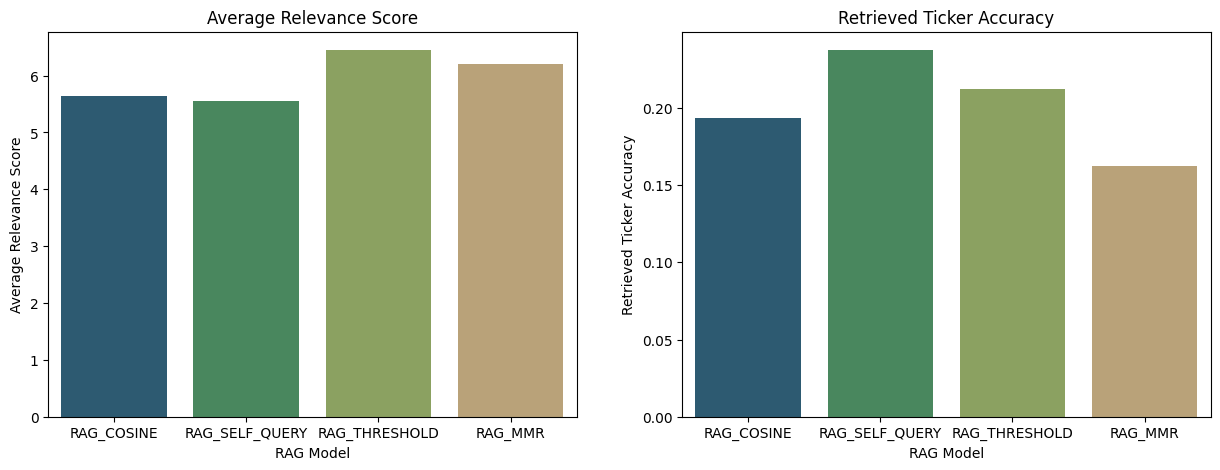

In [30]:
retrieval_comp_average(llm_results)

Query Time Comparison

In [31]:
llm_comps = {
    "RAG_COSINE": rag_model_8_scores["query_time_results"],
    "RAG_SELF_QUERY": rag_model_6_scores["query_time_results"],
    "RAG_THRESHOLD": rag_model_9_scores["query_time_results"],
    "RAG_MMR": rag_model_10_scores["query_time_results"]
}

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

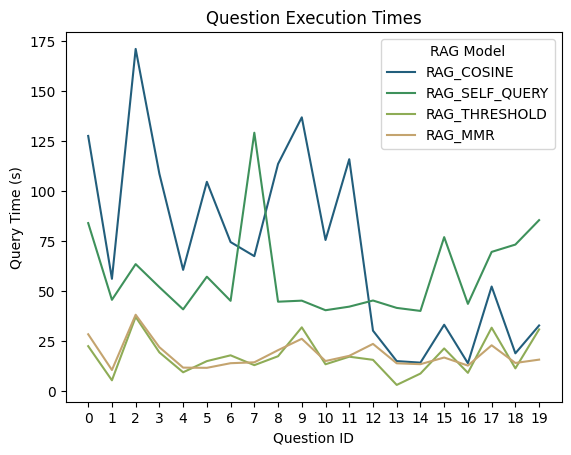

In [32]:
query_times_comp(llm_comps)

<module 'matplotlib.pyplot' from 'C:\\Users\\bkear\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

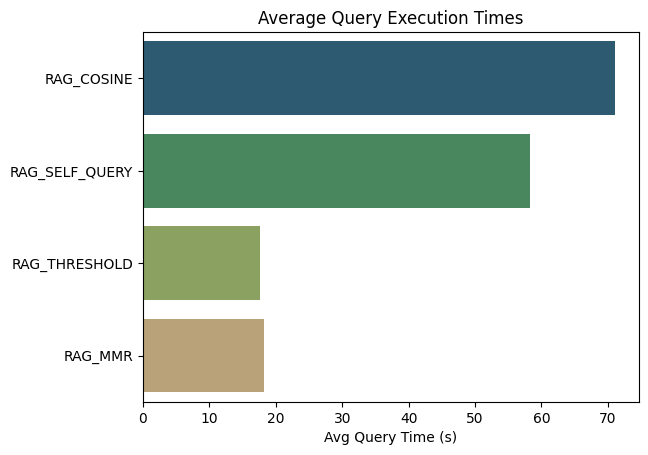

In [33]:
compare_avg_times(llm_comps)